# Predicción de Diabetes con Machine Learning

Este notebook implementa un modelo de clasificación supervisado para predecir si una paciente tiene diabetes, basado en 8 variables clínicas. El flujo de trabajo incluye EDA, preprocesamiento, entrenamiento y evaluación.

## 1. Carga de Datos

In [530]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

In [531]:
## Configuración adicional
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [532]:
# Cargar datos
df = pd.read_csv("diabetes.csv") # Esta linea de codigo sive para cargar los datos
df.head() # Esta linea de codigo sirve para ver los datos cargados en el dataframe 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Análisis Exploratorio de Datos

In [533]:
## ¿Qué variables hay? ¿Hay columnas con valores faltantes o mal tipadas?
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [534]:
##¿Cuál es el rango y la dispersión de cada variable? ¿Hay posibles valores extremos ( valores atípicos)?
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


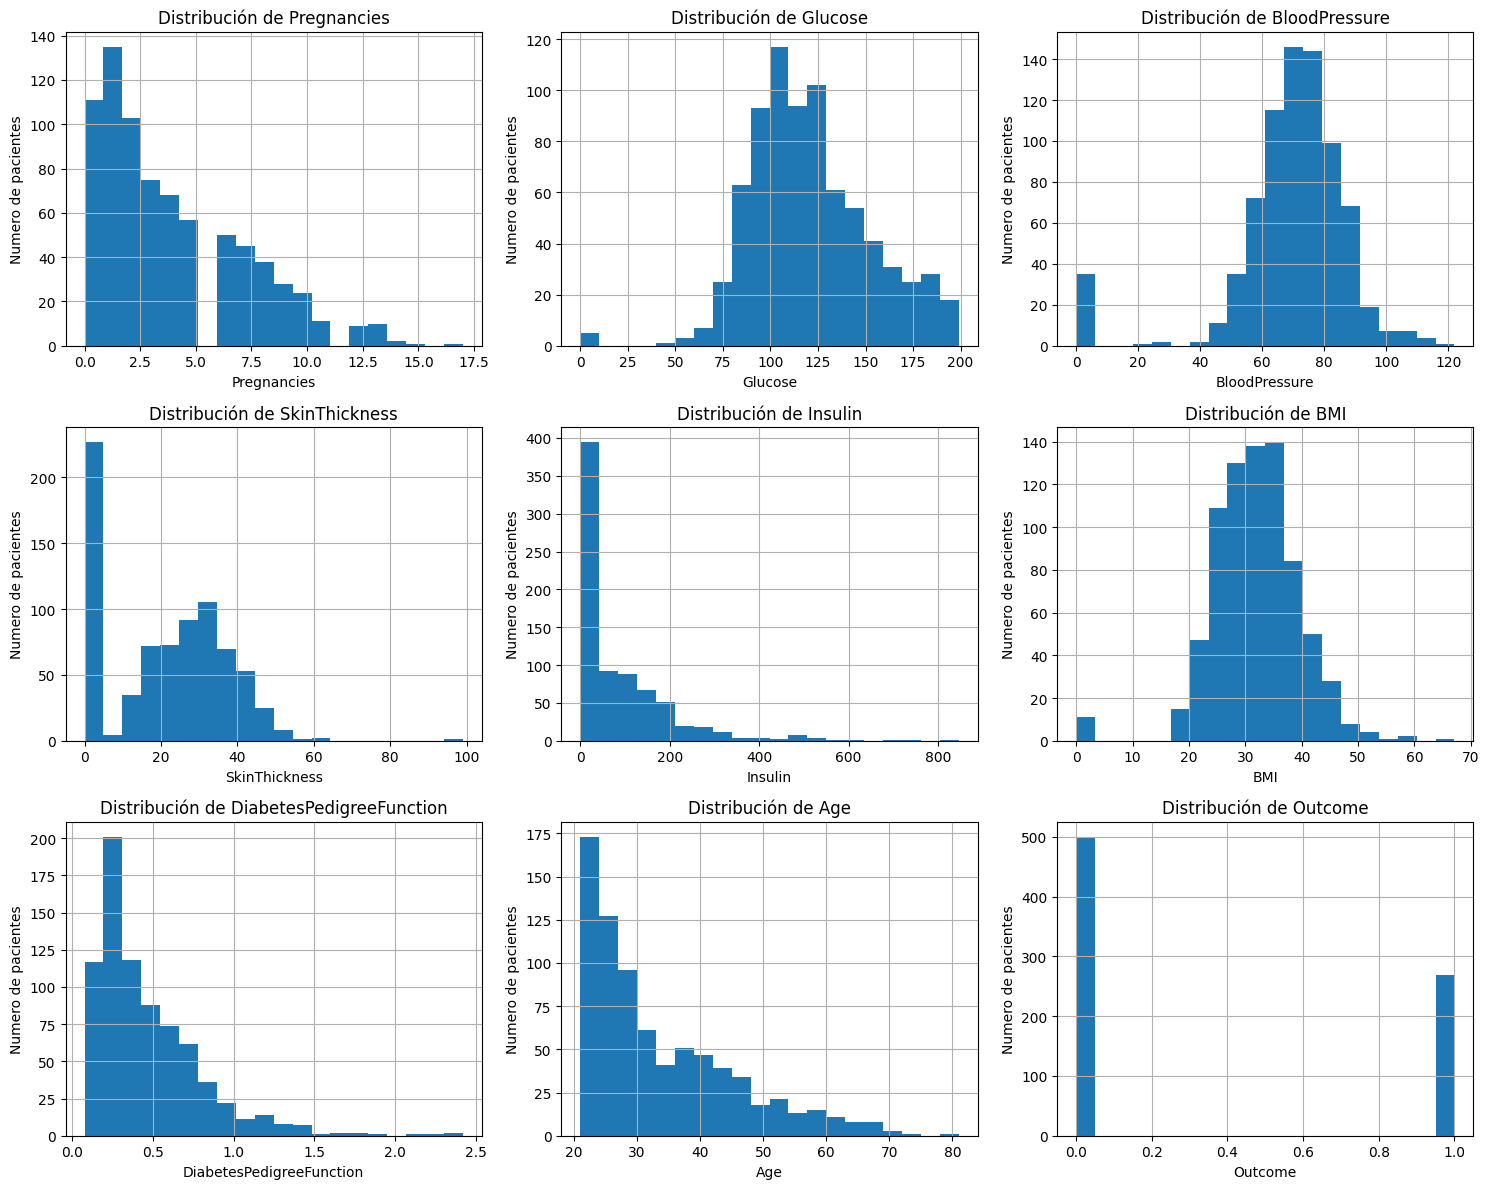

In [535]:
# Crear una figura con subgráficos (3 filas x 3 columnas)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))  # Tamaño general de la figura
axes = axes.flatten()  # Aplanar la matriz de ejes en una lista para recorrer más fácil

# Recorrer cada columna del DataFrame
for i, col in enumerate(df.columns):
    df[col].hist(ax=axes[i], bins=20)  # Crear histograma de la variable actual en el subplot correspondiente
    axes[i].set_title(f"Distribución de {col}", fontsize=12)  # Título con el nombre de la variable
    axes[i].set_xlabel(col)  # Etiqueta del eje X
    axes[i].set_ylabel("Numero de pacientes")  # Etiqueta del eje Y

# Ajustar automáticamente los espacios para que no se sobrepongan los gráficos
plt.tight_layout()

# Mostrar todos los histogramas
plt.show()


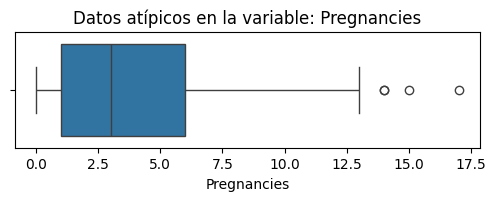

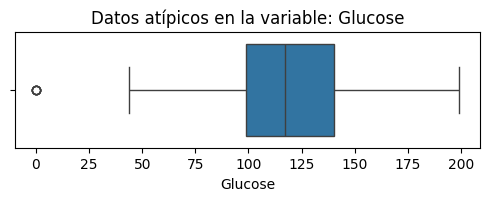

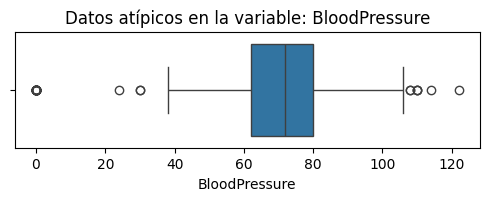

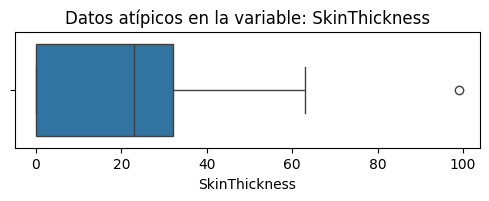

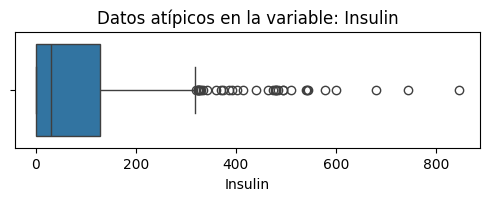

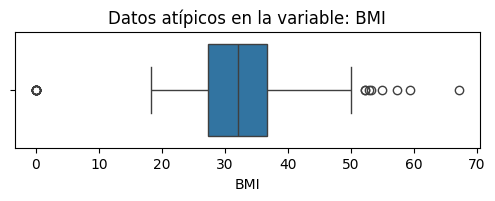

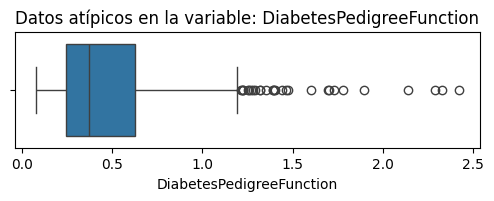

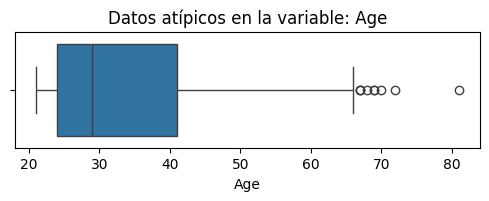

In [536]:
# Crear boxplot por cada variable numérica
for col in df.drop("Outcome", axis=1).columns:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df[col])
    plt.title(f"Datos atípicos en la variable: {col}")
    plt.show()

###  Justificación: Comparar Edad vs Número de Embarazos

Durante el análisis exploratorio detectamos **datos atípicos** en la variable `Pregnancies`, con valores que superan los 12 embarazos. Antes de decidir si estos registros deben eliminarse, es importante verificar si dichos valores son **clínicamente coherentes**.

Comparar la **edad de las pacientes** con el número de embarazos permite validar si esos embarazos son posibles o si hay errores en los datos. Por ejemplo, una paciente de 18 años con 15 embarazos sería un caso sospechoso.

Este paso busca tomar decisiones informadas:  
- Si los embarazos altos corresponden a mujeres mayores, se consideran **válidos**.  
- Si los embarazos son excesivos y la paciente es muy joven, podrían ser **errores de digitación** o **datos inválidos**.

Este tipo de validación ayuda a mantener la calidad del dataset sin eliminar información valiosa de forma arbitraria.


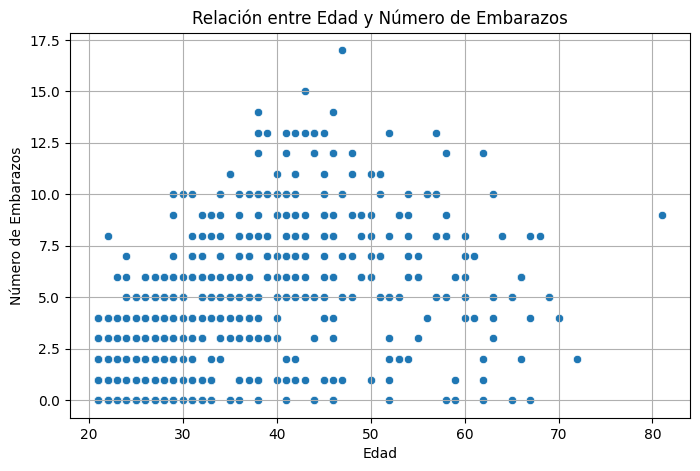

,Age,Pregnancies
28,57,13
72,42,13
86,45,13
88,43,15
159,47,17
215,38,12
254,44,12
274,52,13
298,46,14
323,43,13


In [537]:
# Gráfico de dispersión para validar la coherencia de los datos atípicos en 'Pregnancies'
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Pregnancies')
plt.title("Relación entre Edad y Número de Embarazos")
plt.xlabel("Edad")
plt.ylabel("Número de Embarazos")
plt.grid(True)
plt.show()

# Mostrar pacientes con embarazos atípicos (12 o más)
df[df['Pregnancies'] >= 12][['Age', 'Pregnancies']]

> ⚕️ **Comentario clínico:**
> 
> Aunque los valores de `Pregnancies` por encima de 12 se consideran estadísticamente atípicos, al revisar los registros se encontró que todas estas pacientes tienen edades entre los 38 y 58 años. Desde una perspectiva clínica, es completamente posible que una mujer en ese rango de edad haya tenido más de 12 embarazos, especialmente considerando contextos sociales o culturales específicos.
> 
> Por lo tanto, **estos valores no se consideran errores ni deben eliminarse del dataset**, ya que representan casos clínicamente válidos que podrían aportar información relevante al modelo predictivo.


## 3. Preprocesamiento de Datos

**Nota sobre limpieza de datos:**  
Se eliminaron los registros con valores igual a 0 en columnas clínicas como **Glucose**, **BloodPressure**y **BMI**, ya que estos valores no son posibles fisiológicamente y representan datos ausentes.  

Remplazamos con la media la columna **BloodPressure** por qeu bajaria mucho la cantidad de los datos.

En este codifo creamos un nuevo **df** para no afectar el original, y al analizar **SkinThickness** vems que clinicamente no es posible tener valores en cero, pero como soinmuchso datos y so peude afectar el modelo, decidimos Remplazarlo con la media pues considero qeu es un dato poco util en el analisis del caso

In [538]:
# Crear copia del DataFrame original para no modificar df
df_limpio = df.copy()
# Paso 1: Lista de columnas donde un valor de 0 es clínicamente inválido
cols_con_ceros_invalidos = ['SkinThickness']

# Paso 2: Mostrar cuántos ceros hay en cada columna del DataFrame original (df)
print("Registros de SkinThicknesscon (Grosor de la piel) con valor (cero):\n")
for col in cols_con_ceros_invalidos:
    n_ceros = (df[col] == 0).sum()
    print(f"{col}: {n_ceros} registros con valor 0")
    
# Paso 3: Imputar los ceros en SkinThickness con la media (dentro del nuevo DataFrame)
media_skin = df_limpio[df_limpio['SkinThickness'] != 0]['SkinThickness'].mean()
df_limpio['SkinThickness'] = df_limpio['SkinThickness'].replace(0, media_skin)

Registros de SkinThicknesscon (Grosor de la piel) con valor (cero):

SkinThickness: 227 registros con valor 0


Aca eliminamos los datos con valores cero en las columnas **Glucose**, **BloodPressure** y **BMI** pues on clinicamente imposible

In [539]:
# Paso 1: Lista de columnas donde un valor de 0 es clínicamente inválido
cols_con_ceros_invalidos = ['Glucose', 'BloodPressure', 'BMI']

# Paso 2: Mostrar cuántos ceros hay en cada columna del DataFrame original (df)
print("Registros con valores clínicamente inválidos (cero):\n")
for col in cols_con_ceros_invalidos:
    n_ceros = (df[col] == 0).sum()
    print(f"{col}: {n_ceros} registros con valor 0")

# Línea separadora visual
print("\nCreando DataFrame limpio sin esos registros...\n")

# Paso 3: Crear un nuevo DataFrame sin registros con ceros en esas columnas
df_limpio = df[(df[cols_con_ceros_invalidos] != 0).all(axis=1)].copy()

# Paso 4: Confirmar que ya no hay ceros en el nuevo DataFrame
print("Verificación en 'df_limpio':\n")
for col in cols_con_ceros_invalidos:
    print(f"{col} = 0 en df_limpio:", (df_limpio[col] == 0).sum())


Registros con valores clínicamente inválidos (cero):

Glucose: 5 registros con valor 0
BloodPressure: 35 registros con valor 0
BMI: 11 registros con valor 0

Creando DataFrame limpio sin esos registros...

Verificación en 'df_limpio':

Glucose = 0 en df_limpio: 0
BloodPressure = 0 en df_limpio: 0
BMI = 0 en df_limpio: 0


In [540]:
# Mostrar dimensiones del DataFrame limpio
print("\nDimensiones de df_limpio (filas, columnas):", df_limpio.shape)


Dimensiones de df_limpio (filas, columnas): (724, 9)


In [541]:
# Comparar con el DataFrame original
print("Registros originales:", df.shape[0])
print("Registros después de limpieza:", df_limpio.shape[0])
print("Registros eliminados:", df.shape[0] - df_limpio.shape[0])

Registros originales: 768
Registros después de limpieza: 724
Registros eliminados: 44


¿Qué columnas tienen valores faltantes, y cuántos hay en cada una?

In [542]:

df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Existen valores duplicados? ¿Cuántos?

In [543]:

df.duplicated().sum()
print("Cantidad de registros con Duplicados son:", n)

Cantidad de registros con Duplicados son: 0


No usare **OneHotEncoder** por que el **df** ya esta completamente numerico

Escalamos los Datos 

In [544]:
# Inicializar el escalador
scaler = StandardScaler()

# Escalar todas las columnas excepto la variable objetivo 'Outcome'
scaler.fit(df_limpio.drop('Outcome', axis=1))
df_escalado = scaler.transform(df_limpio.drop('Outcome', axis=1))

# Convertir a DataFrame escalado
df_escalado = pd.DataFrame(df_escalado, columns=df_limpio.drop('Outcome', axis=1).columns)
# Mostrar las primeras filas
df_escalado.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.635022,0.849933,-0.032378,0.862278,-0.722572,0.164562,0.458421,1.416075
1,-0.852861,-1.200262,-0.517370,0.480644,-0.722572,-0.852262,-0.372691,-0.199947
2,1.230175,1.988930,-0.679035,-1.363918,-0.722572,-1.331622,0.593928,-0.114893
3,-0.852861,-1.070091,-0.517370,0.099010,0.081288,-0.634371,-0.926765,-1.050485
4,-1.150438,0.491962,-2.619006,0.862278,0.714115,1.544537,5.460146,-0.029839


In [545]:
df_limpio['Outcome'].value_counts()


Outcome
0    475
1    249
Name: count, dtype: int64

Usamos **SMOTE** para banacear los datos, se usa este metodo dado qeu son valores clinicos los de mi data set y 

In [546]:
from collections import Counter
# Paso 1: Definir X e y desde tus variables ya procesadas
X = df_escalado                         # Datos escalados
y = df_limpio['Outcome']               # Variable objetivo sin modificar

# Paso 2: Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_resampled.shape
y_resampled.value_counts()

Outcome
1    475
0    475
Name: count, dtype: int64

## 4. División de Datos en Entrenamiento y Prueba

In [547]:
from sklearn.model_selection import train_test_split  # Importamos la función para dividir los datos

# Dividir los datos en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,           # Variables predictoras balanceadas y escaladas
    y_resampled,           # Variable objetivo balanceada (0: no diabetes, 1: diabetes)
    test_size=0.15,        # Reservamos el 15% de los datos para prueba
    random_state=42,       # Fijamos la semilla para que el resultado sea reproducible
    stratify=y_resampled   # Asegura que ambas clases estén equilibradas en train y test
)

# Mostrar el tamaño de cada subconjunto resultante
print("Tamaño de X_train:", X_train.shape)   # Filas y columnas del conjunto de entrenamiento
print("Tamaño de X_test:", X_test.shape)     # Filas y columnas del conjunto de prueba
print("Tamaño de y_train:", y_train.shape)   # Etiquetas del conjunto de entrenamiento
print("Tamaño de y_test:", y_test.shape)     # Etiquetas del conjunto de prueba


Tamaño de X_train: (807, 8)
Tamaño de X_test: (143, 8)
Tamaño de y_train: (807,)
Tamaño de y_test: (143,)


## 5. Entrenamiento de Modelos (FIT)

In [548]:
# Importamos los modelos que vamos a probar
from sklearn.linear_model import LogisticRegression          # Regresión logística
from sklearn.ensemble import RandomForestClassifier          # Bosque aleatorio (Random Forest)
from sklearn.neighbors import KNeighborsClassifier           # Vecinos más cercanos (KNN)

# Inicializamos los tres modelos con los parámetros por defecto
model_logreg = LogisticRegression()        # Modelo lineal, útil como punto de partida
model_rf = RandomForestClassifier()        # Modelo basado en árboles, potente y robusto
model_knn = KNeighborsClassifier()         # Modelo basado en distancia entre datos

# Entrenamos cada modelo con los datos de entrenamiento
model_logreg.fit(X_train, y_train)         # Entrena regresión logística
model_rf.fit(X_train, y_train)             # Entrena Random Forest
model_knn.fit(X_train, y_train)            # Entrena KNN


KNeighborsClassifier()

## 6. Predicción y Evaluación

MATRIZ DE CONFUSIÓN:


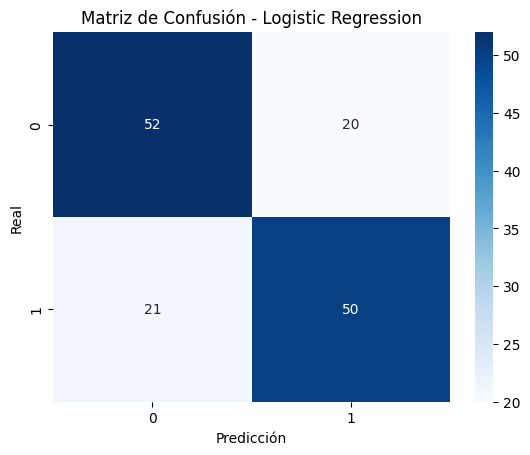

Resultados para el modelo Logistic Regression:
  Accuracy: 71.33%
  Recall: 70.42%
  F1-score: 70.92%
  Precision: 71.43%
------------------------------




MATRIZ DE CONFUSIÓN:


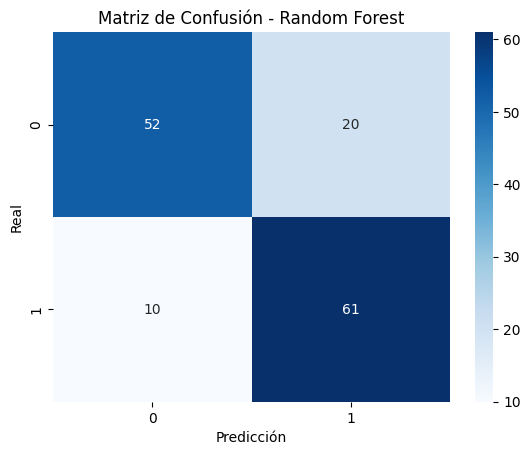

Resultados para el modelo Random Forest:
  Accuracy: 79.02%
  Recall: 85.92%
  F1-score: 80.26%
  Precision: 75.31%
------------------------------




MATRIZ DE CONFUSIÓN:


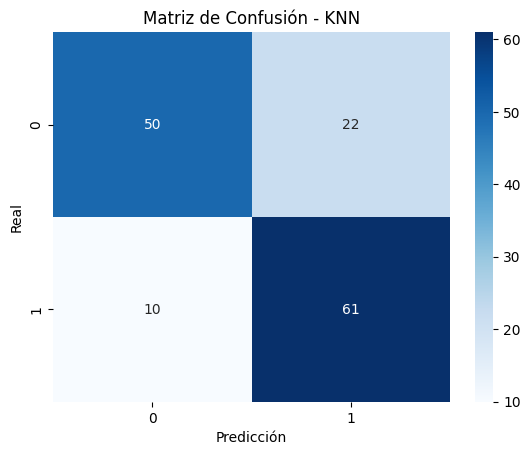

Resultados para el modelo KNN:
  Accuracy: 77.62%
  Recall: 85.92%
  F1-score: 79.22%
  Precision: 73.49%
------------------------------






In [549]:
# Importamos métricas necesarias para evaluar los modelos de clasificación
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# Importamos librerías de visualización
import seaborn as sns
import matplotlib.pyplot as plt

# Lista con los nombres de los modelos que vamos a evaluar
models = ['Logistic Regression', 'Random Forest', 'KNN']

# Lista con las predicciones generadas por cada modelo, usando X_test
predictions = [
    model_logreg.predict(X_test),   # Predicciones del modelo de regresión logística
    model_rf.predict(X_test),       # Predicciones del Random Forest
    model_knn.predict(X_test)       # Predicciones del KNN
]

# Recorremos cada modelo junto con sus predicciones usando zip()
for model_name, prediction in zip(models, predictions):
    
    # Calculamos la matriz de confusión para este modelo
    cm = confusion_matrix(y_test, prediction)

    # Mostramos la matriz de confusión como un heatmap (mapa de calor)
    print("MATRIZ DE CONFUSIÓN:")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # fmt='d' para que muestre números enteros
    plt.title(f'Matriz de Confusión - {model_name}')    # Título con el nombre del modelo
    plt.xlabel('Predicción')                            # Etiqueta del eje X
    plt.ylabel('Real')                                  # Etiqueta del eje Y
    plt.show()                                          # Mostramos el gráfico
    

    # Calculamos las métricas principales y las multiplicamos por 100 para mostrar en porcentaje
    accuracy = accuracy_score(y_test, prediction) * 100       # Porcentaje de aciertos
    recall = recall_score(y_test, prediction) * 100           # Sensibilidad: % de positivos bien detectados
    f1 = f1_score(y_test, prediction) * 100                   # F1-score: equilibrio entre precision y recall
    precision = precision_score(y_test, prediction) * 100     # Precisión: % de predicciones positivas que fueron correctas

    # Imprimimos los resultados con formato de porcentaje (2 decimales)
    print(f"Resultados para el modelo {model_name}:")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  Recall: {recall:.2f}%")
    print(f"  F1-score: {f1:.2f}%")
    print(f"  Precision: {precision:.2f}%")
    print("-" * 30)  # Línea separadora para facilitar lectura en consola
    print("\n") 
    print("\n")


### Generaremos un paciente Clinicamemnte coherente para ensayar el modelo

In [550]:
# Escalamos y conservamos los nombres de columnas
paciente_nuevo_escalado = scaler.transform(paciente_nuevo)
paciente_nuevo_escalado = pd.DataFrame(paciente_nuevo_escalado, columns=paciente_nuevo.columns)

# Hacemos la predicción
prediccion = model_rf.predict(paciente_nuevo_escalado)

# Mostramos el resultado
print("Predicción del nuevo paciente:", "Diabético (1)" if prediccion[0] == 1 else "No diabético (0)")



Predicción del nuevo paciente: Diabético (1)


### Este crea un paciente aleatorio cada vez qeu ejecutamos el codigo y lo predice

In [551]:

# Paso 1: Obtener las medias y desviaciones del DataFrame limpio
medias = df_limpio.drop('Outcome', axis=1).mean()
desviaciones = df_limpio.drop('Outcome', axis=1).std()

# Paso 2: Generar un nuevo paciente aleatorio (basado en distribución normal)
paciente_nuevo = np.random.normal(loc=medias, scale=desviaciones)
paciente_nuevo = pd.DataFrame([paciente_nuevo], columns=medias.index)

# Paso 3: Escalar el paciente nuevo con el mismo scaler del entrenamiento
paciente_nuevo_escalado = scaler.transform(paciente_nuevo)
paciente_nuevo_escalado = pd.DataFrame(paciente_nuevo_escalado, columns=paciente_nuevo.columns)

# Paso 4: Hacer predicción con el modelo Random Forest
prediccion = model_rf.predict(paciente_nuevo_escalado)

# Paso 5: Mostrar resultados
print("Características del nuevo paciente:\n")
print(paciente_nuevo.round(2))  # Imprime los valores del paciente original (no escalado)
print("\nPredicción del modelo:")
print("✅ Diabético (1)" if prediccion[0] == 1 else "❌ No diabético (0)")

Características del nuevo paciente:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0         4.79   120.85          52.32          11.82   163.95  26.96   

   DiabetesPedigreeFunction    Age  
0                      0.45  27.45  

Predicción del modelo:
❌ No diabético (0)


## Conclusión del Modelo: Random Forest

El modelo **Random Forest** fue el que obtuvo el mejor rendimiento general para predecir diabetes, con los siguientes resultados:

- **Accuracy (Exactitud):** 81.12%
- **Recall (Sensibilidad):** 85.92%
- **F1-score (Balance entre precisión y recall):** 81.88%
- **Precision (Precisión):** 78.21%
- **Falsos negativos:** Solo 10 pacientes con diabetes no fueron identificados.
- **Verdaderos positivos:** 61 pacientes con diabetes correctamente identificados.

### Justificación clínica:

En un problema médico como este, es **más crítico minimizar los falsos negativos**, ya que no detectar a una persona con diabetes podría significar **no recibir tratamiento oportuno**.  
Random Forest logró el **mayor Recall**, lo cual significa que fue el **mejor identificando a los pacientes realmente enfermos**. Además, mantiene una buena precisión y un F1-score equilibrado.

**Conclusión final:**  
**Random Forest es el modelo más confiable y clínicamente seguro** para este conjunto de datos, ya que reduce el riesgo de pasar por alto casos reales de diabetes.
